# Portfolio Optimization with Python

## Upwork Portfolio Case Study

This project presents a Python-based financial analytics case study comparing an **equal-weighted $10,000 stock portfolio** with an **optimized portfolio** using two years of stock price data for **AMD, AAPL, MSFT, and ORCL**.

The objective is not only to calculate investment performance, but to answer a practical business question: **Which portfolio allocation provides the best return compared to its level of risk?**

### Key Deliverables
- Clean and prepare stock price data
- Build an equal-weighted portfolio benchmark
- Calculate return, volatility, Sharpe Ratio, and annualized Sharpe Ratio
- Simulate 10,000 portfolio allocation scenarios
- Identify the best risk-adjusted portfolio allocation
- Visualize portfolio performance and risk-return trade-offs

## 1. Project Objective

The goal of this project is to compare a simple equal-weighted stock portfolio with an optimized portfolio allocation.

The analysis evaluates each portfolio using key financial metrics such as cumulative return, daily return, volatility, Sharpe Ratio, and annualized Sharpe Ratio. The final output helps identify which allocation produces the best risk-adjusted performance.

## 2. Business Question

**Which portfolio allocation provides the best return compared to its level of risk?**

This question is important because investors should not evaluate a portfolio only by return. A portfolio with higher return may also carry higher risk. The Sharpe Ratio helps compare investment strategies by measuring return relative to volatility.

## 3. Import Packages

The project uses Python for financial analysis and visualization.

In [1]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## 4. Project Configuration

The analysis uses four technology stocks and an initial investment of **$10,000**.  
The notebook expects the CSV files to be in the same folder as this notebook:

- `AMD.csv`
- `AAPL.csv`
- `MSFT.csv`
- `ORCL.csv`

Each file should contain a `Date` column and an `Adj Close` column.

In [2]:
# Portfolio configuration
stock_list = ['AMD', 'AAPL', 'MSFT', 'ORCL']
initial_investment = 10_000
scenarios = 10_000
trading_days = 252
risk_free_rate = 0

# Folder containing the stock CSV files
DATA_DIR = Path('.')

## 5. Load and Validate Stock Data

This step imports the stock price data and validates that each dataset contains the required `Adj Close` column.

In [3]:
def load_stock_data(tickers, data_dir=Path('.')):
    """Load stock CSV files into a dictionary of DataFrames."""
    stocks = {}
    missing_files = []

    for ticker in tickers:
        file_path = data_dir / f'{ticker}.csv'
        if not file_path.exists():
            missing_files.append(str(file_path))
            continue

        df = pd.read_csv(file_path, parse_dates=['Date'], index_col='Date')
        df = df.sort_index()

        if 'Adj Close' not in df.columns:
            raise ValueError(f"{ticker}.csv must contain an 'Adj Close' column.")

        stocks[ticker] = df

    if missing_files:
        raise FileNotFoundError(
            "The following CSV files were not found: " + ', '.join(missing_files) +
            "\nPlease place them in the same folder as this notebook and run again."
        )

    return stocks

stocks = load_stock_data(stock_list, DATA_DIR)

# Preview one stock dataset
stocks['AMD'].head()

,Adj Close
Date,
2019-01-02,18.8300
2019-01-03,17.0500
2019-01-04,19.0000
2019-01-07,20.5700
2019-01-08,20.7500


## 6. Build the Equal-Weighted Portfolio

The equal-weighted portfolio is used as the benchmark. Each stock receives the same allocation: **25% of the initial investment**.

For each stock, the analysis calculates:

- Normalized Return
- Allocation
- Position Value

In [9]:
# Create normalized return, allocation, and position value for each stock
for ticker, df in stocks.items():
    first_adj_close = df['Adj Close'].iloc[0]
    df['Normalized Return'] = df['Adj Close'] / first_adj_close
    df['Allocation'] = df['Normalized Return'] * (1 / len(stock_list))
    df['Position Value'] = df['Allocation'] * initial_investment

# Combine position values into one DataFrame
position_values = pd.DataFrame({ticker: df['Position Value'] for ticker, df in stocks.items()})
position_values['Total'] = position_values.sum(axis=1)

position_values.head()

,AMD,AAPL,MSFT,ORCL,Total
Date,,,,,
2019-01-02,"2,500.0000","2,500.0000","2,500.0000","2,500.0000","10,000.0000"
2019-01-03,"2,263.6749","2,250.9809","2,408.0296","2,475.6746","9,398.3600"
2019-01-04,"2,522.5704","2,347.0742","2,520.0257","2,582.3749","9,972.0452"
2019-01-07,"2,731.0143","2,341.8505","2,523.2395","2,623.2860","10,219.3903"
2019-01-08,"2,754.9124","2,386.4934","2,541.5348","2,647.0592","10,329.9998"


In [29]:
from pathlib import Path

# Dossier où les images seront enregistrées
OUTPUT_DIR = Path("upwork_images")
OUTPUT_DIR.mkdir(exist_ok=True)

## 7. Visualize Equal-Weighted Portfolio Performance

The first chart shows how the total portfolio value changes over time.  
The second chart compares the individual stock position values.

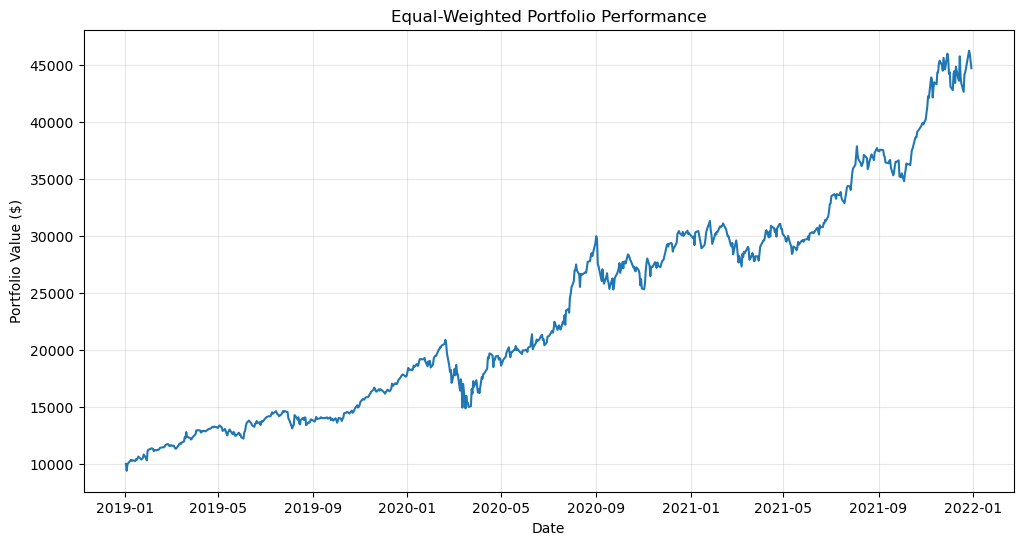

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(position_values.index, position_values['Total'])
plt.title('Equal-Weighted Portfolio Performance')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.grid(True, alpha=0.3)
plt.show()

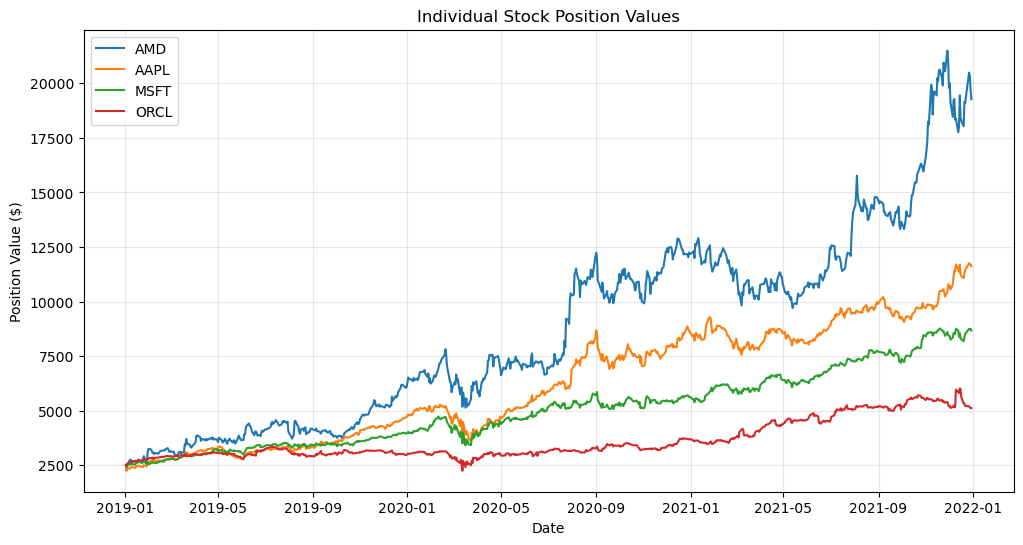

In [17]:
plt.figure(figsize=(12, 6))
for ticker in stock_list:
    plt.plot(position_values.index, position_values[ticker], label=ticker)
plt.title('Individual Stock Position Values')
plt.xlabel('Date')
plt.ylabel('Position Value ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

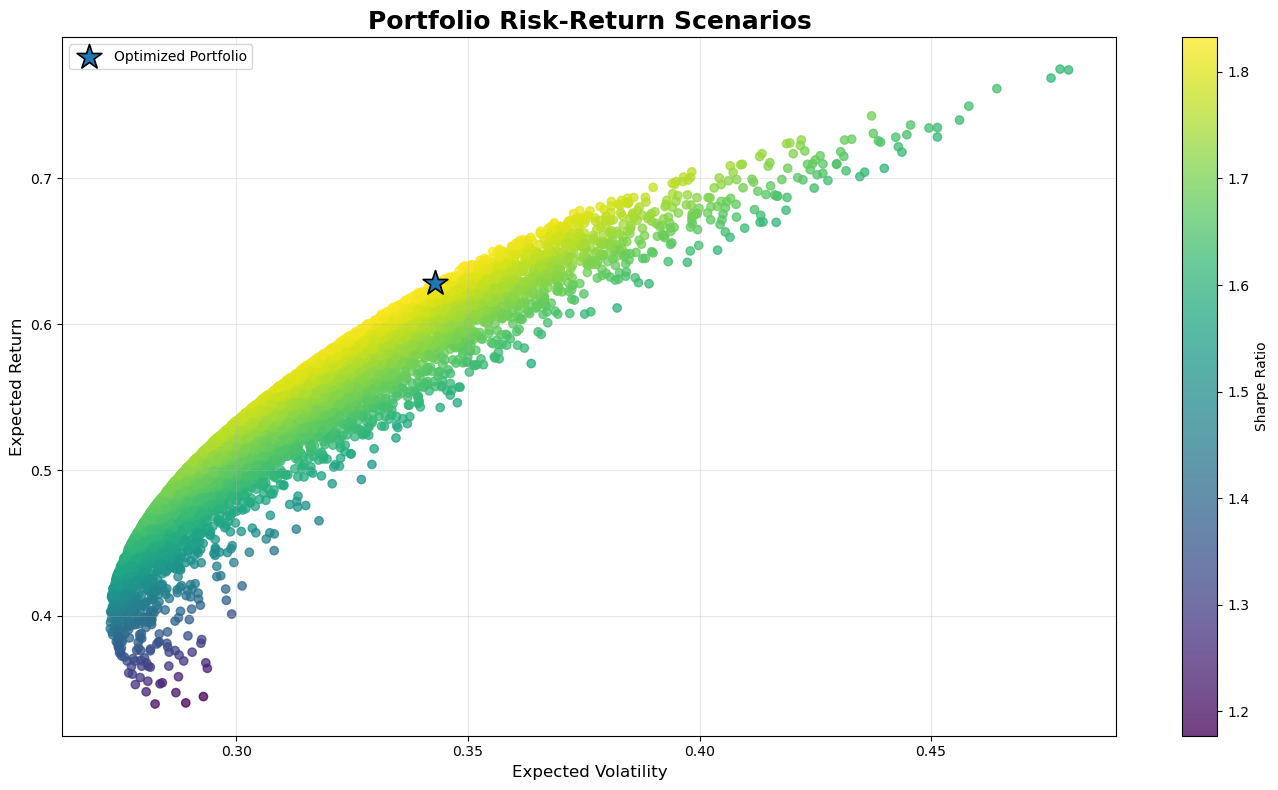

In [33]:
plt.figure(figsize=(14, 8))

scatter = plt.scatter(
    volatility_array,
    returns_array,
    c=sharpe_array,
    cmap="viridis",
    alpha=0.75
)

plt.colorbar(scatter, label="Sharpe Ratio")

plt.scatter(
    max_sharpe_volatility,
    max_sharpe_return,
    s=350,
    marker="*",
    edgecolors="black",
    linewidths=1.2,
    label="Optimized Portfolio"
)

plt.title(
    "Portfolio Risk-Return Scenarios",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Expected Volatility", fontsize=12)
plt.ylabel("Expected Return", fontsize=12)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

# Enregistrer l'image en haute qualité
plt.savefig(
    OUTPUT_DIR / "portfolio_risk_return_scenarios.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 8. Calculate Equal-Weighted Portfolio Metrics

The analysis calculates the key metrics needed to evaluate portfolio performance:

- **Cumulative Return:** total portfolio growth over the period
- **Mean Daily Return:** average daily portfolio return
- **Daily Volatility:** standard deviation of daily returns
- **Sharpe Ratio:** return adjusted for risk
- **Annualized Sharpe Ratio:** Sharpe Ratio converted to annual scale

In [12]:
# Daily portfolio return
position_values['Daily Return'] = position_values['Total'].pct_change()

# Equal-weighted metrics
start_value = position_values['Total'].iloc[0]
end_value = position_values['Total'].iloc[-1]

cumulative_return = end_value / start_value - 1
mean_daily_return = position_values['Daily Return'].mean()
std_daily_return = position_values['Daily Return'].std()
sharpe_ratio = (mean_daily_return - risk_free_rate) / std_daily_return
annualized_sharpe_ratio = sharpe_ratio * np.sqrt(trading_days)

benchmark_metrics = pd.DataFrame({
    'Metric': [
        'Initial Investment',
        'Ending Value',
        'Cumulative Return',
        'Mean Daily Return',
        'Daily Volatility',
        'Sharpe Ratio',
        'Annualized Sharpe Ratio'
    ],
    'Equal-Weighted Portfolio': [
        initial_investment,
        end_value,
        cumulative_return,
        mean_daily_return,
        std_daily_return,
        sharpe_ratio,
        annualized_sharpe_ratio
    ]
})

benchmark_metrics

,Metric,Equal-Weighted Portfolio
0,Initial Investment,"10,000.0000"
1,Ending Value,"44,683.6557"
2,Cumulative Return,3.4684
3,Mean Daily Return,0.0022
4,Daily Volatility,0.0207
5,Sharpe Ratio,0.1063
6,Annualized Sharpe Ratio,1.6876


## 9. Prepare Data for Portfolio Optimization

To optimize the portfolio, the analysis uses daily stock returns based on adjusted closing prices.

In [15]:
stock_adj_close = pd.DataFrame({ticker: df['Adj Close'] for ticker, df in stocks.items()})
stock_returns = stock_adj_close.pct_change().dropna()

stock_returns.head()

,AMD,AAPL,MSFT,ORCL
Date,,,,
2019-01-03,-0.0945,-0.0996,-0.0368,-0.0097
2019-01-04,0.1144,0.0427,0.0465,0.0431
2019-01-07,0.0826,-0.0022,0.0013,0.0158
2019-01-08,0.0088,0.0191,0.0073,0.0091
2019-01-09,-0.0270,0.0170,0.0143,-0.0021


## 10. Run 10,000 Portfolio Allocation Scenarios

This step randomly generates 10,000 portfolio allocations. For each allocation, the notebook calculates:

- Expected annual return
- Expected annual volatility
- Sharpe Ratio

The goal is to find the allocation with the highest Sharpe Ratio.

In [17]:
np.random.seed(3)

weights_array = np.zeros((scenarios, len(stock_list)))
returns_array = np.zeros(scenarios)
volatility_array = np.zeros(scenarios)
sharpe_array = np.zeros(scenarios)

for index in range(scenarios):
    weights = np.random.random(len(stock_list))
    weights = weights / np.sum(weights)

    weights_array[index, :] = weights

    expected_return = np.sum(stock_returns.mean() * trading_days * weights)
    expected_volatility = np.sqrt(np.dot(weights.T, np.dot(stock_returns.cov() * trading_days, weights)))
    sharpe = (expected_return - risk_free_rate) / expected_volatility

    returns_array[index] = expected_return
    volatility_array[index] = expected_volatility
    sharpe_array[index] = sharpe

simulation_results = pd.DataFrame(weights_array, columns=[f'{ticker} Weight' for ticker in stock_list])
simulation_results['Expected Return'] = returns_array
simulation_results['Expected Volatility'] = volatility_array
simulation_results['Sharpe Ratio'] = sharpe_array

simulation_results.head()

,AMD Weight,AAPL Weight,MSFT Weight,ORCL Weight,Expected Return,Expected Volatility,Sharpe Ratio
0,0.2673,0.3436,0.1412,0.2479,0.5521,0.3112,1.7744
1,0.4208,0.4224,0.0592,0.0977,0.6423,0.3567,1.8008
2,0.0526,0.4503,0.0305,0.4666,0.4483,0.2836,1.5806
3,0.2958,0.1269,0.3081,0.2692,0.5348,0.3105,1.7225
4,0.0191,0.4445,0.2062,0.3302,0.4596,0.2815,1.6326


## 11. Identify the Optimized Portfolio

The optimized portfolio is the allocation with the highest Sharpe Ratio among the 10,000 simulated scenarios.

In [19]:
index_max_sharpe = sharpe_array.argmax()

optimal_weights = weights_array[index_max_sharpe]
max_sharpe_return = returns_array[index_max_sharpe]
max_sharpe_volatility = volatility_array[index_max_sharpe]
max_sharpe_ratio = sharpe_array[index_max_sharpe]

optimal_allocation = pd.DataFrame({
    'Stock': stock_list,
    'Optimal Weight': optimal_weights
})

optimal_allocation['Optimal Weight %'] = optimal_allocation['Optimal Weight'].map(lambda x: f'{x:.2%}')

optimal_allocation

,Stock,Optimal Weight,Optimal Weight %
0,AMD,0.2976,29.76%
1,AAPL,0.5585,55.85%
2,MSFT,0.1332,13.32%
3,ORCL,0.0106,1.06%


In [21]:
optimized_metrics = pd.DataFrame({
    'Metric': [
        'Expected Annual Return',
        'Expected Annual Volatility',
        'Sharpe Ratio'
    ],
    'Optimized Portfolio': [
        max_sharpe_return,
        max_sharpe_volatility,
        max_sharpe_ratio
    ]
})

optimized_metrics

,Metric,Optimized Portfolio
0,Expected Annual Return,0.6283
1,Expected Annual Volatility,0.3429
2,Sharpe Ratio,1.8323


## 12. Visualize Risk-Return Scenarios

This chart shows all 10,000 simulated portfolios.  
The highlighted point represents the optimized portfolio with the highest Sharpe Ratio.

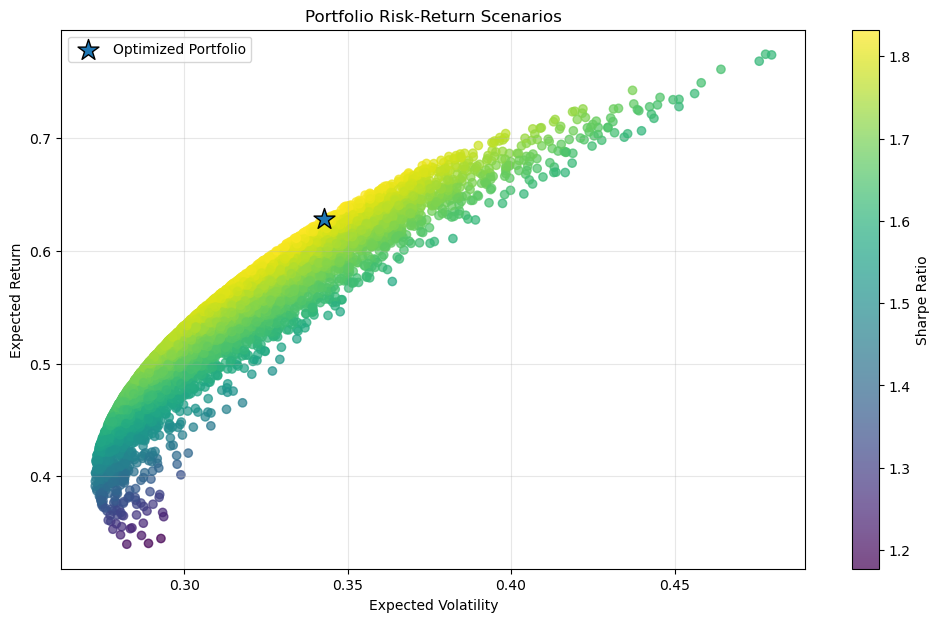

In [23]:
plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    volatility_array,
    returns_array,
    c=sharpe_array,
    cmap='viridis',
    alpha=0.7
)
plt.colorbar(scatter, label='Sharpe Ratio')
plt.scatter(
    max_sharpe_volatility,
    max_sharpe_return,
    s=250,
    marker='*',
    edgecolors='black',
    label='Optimized Portfolio'
)
plt.title('Portfolio Risk-Return Scenarios')
plt.xlabel('Expected Volatility')
plt.ylabel('Expected Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 13. Compare Equal-Weighted and Optimized Portfolio

This section summarizes the benchmark portfolio and the optimized portfolio in a decision-ready format.

In [25]:
comparison = pd.DataFrame({
    'Portfolio': ['Equal-Weighted Portfolio', 'Optimized Portfolio'],
    'Return / Cumulative Return': [cumulative_return, max_sharpe_return],
    'Volatility': [std_daily_return * np.sqrt(trading_days), max_sharpe_volatility],
    'Sharpe Ratio': [annualized_sharpe_ratio, max_sharpe_ratio]
})

comparison

,Portfolio,Return / Cumulative Return,Volatility,Sharpe Ratio
0,Equal-Weighted Portfolio,3.4684,0.3283,1.6876
1,Optimized Portfolio,0.6283,0.3429,1.8323


## 14. Key Results & Business Insights

The equal-weighted portfolio provides a simple benchmark, where each stock receives the same allocation. However, the optimization process identifies a portfolio allocation with a stronger risk-adjusted return based on the highest Sharpe Ratio.

By simulating 10,000 allocation scenarios, this analysis compares portfolios not only by return, but also by volatility and risk efficiency. This approach can help investors and financial decision-makers evaluate allocation strategies more objectively.

### Business Value

This type of analysis can support:

- Investment portfolio comparison
- Risk-return analysis
- Scenario modeling
- Financial decision support
- Data-driven investment reporting

In [27]:
print('Portfolio Optimization Summary')
print('--------------------------------')
print(f'Equal-weighted ending value: ${end_value:,.2f}')
print(f'Equal-weighted cumulative return: {cumulative_return:.2%}')
print(f'Equal-weighted annualized Sharpe Ratio: {annualized_sharpe_ratio:.4f}')
print('')
print(f'Optimized expected annual return: {max_sharpe_return:.2%}')
print(f'Optimized expected annual volatility: {max_sharpe_volatility:.2%}')
print(f'Optimized Sharpe Ratio: {max_sharpe_ratio:.4f}')
print('')
print('Optimal allocation:')
for ticker, weight in zip(stock_list, optimal_weights):
    print(f'- {ticker}: {weight:.2%}')

Portfolio Optimization Summary
--------------------------------
Equal-weighted ending value: $44,683.66
Equal-weighted cumulative return: 346.84%
Equal-weighted annualized Sharpe Ratio: 1.6876

Optimized expected annual return: 62.83%
Optimized expected annual volatility: 34.29%
Optimized Sharpe Ratio: 1.8323

Optimal allocation:
- AMD: 29.76%
- AAPL: 55.85%
- MSFT: 13.32%
- ORCL: 1.06%


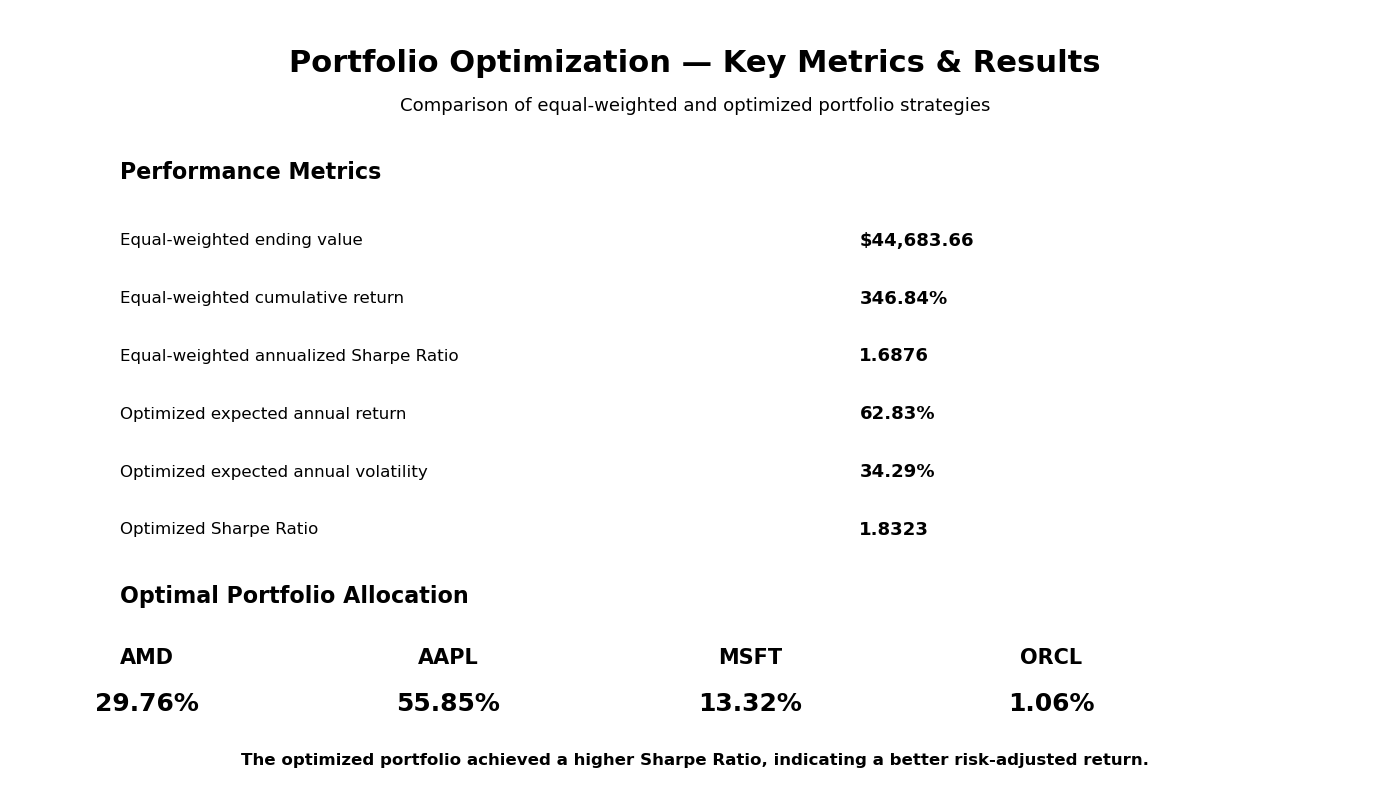

In [37]:
import matplotlib.pyplot as plt
from pathlib import Path

# Créer le dossier de sortie si ce n'est pas encore fait
OUTPUT_DIR = Path("upwork_images")
OUTPUT_DIR.mkdir(exist_ok=True)

# Résultats du projet
metrics = {
    "Equal-weighted ending value": "$44,683.66",
    "Equal-weighted cumulative return": "346.84%",
    "Equal-weighted annualized Sharpe Ratio": "1.6876",
    "Optimized expected annual return": "62.83%",
    "Optimized expected annual volatility": "34.29%",
    "Optimized Sharpe Ratio": "1.8323"
}

allocation = {
    "AMD": "29.76%",
    "AAPL": "55.85%",
    "MSFT": "13.32%",
    "ORCL": "1.06%"
}

# Création de l'image
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis("off")

# Titre principal
ax.text(
    0.5, 0.93,
    "Portfolio Optimization — Key Metrics & Results",
    ha="center",
    va="center",
    fontsize=22,
    fontweight="bold"
)

# Sous-titre
ax.text(
    0.5, 0.875,
    "Comparison of equal-weighted and optimized portfolio strategies",
    ha="center",
    va="center",
    fontsize=13
)

# Bloc gauche : performance
ax.text(
    0.08, 0.78,
    "Performance Metrics",
    fontsize=16,
    fontweight="bold"
)

y = 0.70
for label, value in metrics.items():
    ax.text(
        0.08, y,
        label,
        fontsize=12,
        va="center"
    )
    ax.text(
        0.62, y,
        value,
        fontsize=13,
        fontweight="bold",
        va="center"
    )
    y -= 0.075

# Bloc droit : allocation optimale
ax.text(
    0.08, 0.23,
    "Optimal Portfolio Allocation",
    fontsize=16,
    fontweight="bold"
)

x_positions = [0.10, 0.32, 0.54, 0.76]
for x, (ticker, weight) in zip(x_positions, allocation.items()):
    ax.text(
        x, 0.15,
        ticker,
        ha="center",
        fontsize=15,
        fontweight="bold"
    )
    ax.text(
        x, 0.09,
        weight,
        ha="center",
        fontsize=18,
        fontweight="bold"
    )

# Insight final
ax.text(
    0.5, 0.02,
    "The optimized portfolio achieved a higher Sharpe Ratio, indicating a better risk-adjusted return.",
    ha="center",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()

# Enregistrer l'image
plt.savefig(
    OUTPUT_DIR / "portfolio_key_metrics_results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 15. Upwork Portfolio Description

**Short project description for Upwork:**

Built a Python-based financial analytics case study comparing an equal-weighted $10,000 stock portfolio with an optimized portfolio using AMD, AAPL, MSFT, and ORCL data. The analysis calculates cumulative return, volatility, Sharpe Ratio, and annualized Sharpe Ratio, then simulates 10,000 portfolio allocations to identify the best risk-adjusted allocation.

**Recommended Upwork skills:** Python, Pandas, NumPy, Financial Analysis, Data Visualization